# Implied volatility: recovering sigma from a price

**All prices in this notebook are synthetic** (generated by `black_scholes_price` with a chosen sigma), not real market quotes. The point is to verify that `pricing.implied_vol.implied_volatility` is the correct numerical inverse of `black_scholes_price`: feed it a price generated at a known sigma, and check it recovers that exact sigma.

1. **Single recovery**: generate one price at a known sigma, invert it, compare.
2. **Recovery across a range of true sigmas**: table of true vs. recovered volatility.
3. **Recovering a synthetic "smile"**: generate prices using a strike-dependent sigma (not flat), then recover it strike by strike and check the solver reconstructs the input shape.
4. **Impossible prices**: show the solver explicitly rejecting a price outside the no-arbitrage bounds, instead of returning a meaningless number.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pricing.black_scholes import black_scholes_price
from pricing.implied_vol import implied_volatility

## 1. Single recovery

In [2]:
# Market parameters (same as previous notebooks, for comparability)
S0 = 100.0
K = 100.0
T = 1.0
r = 0.05
q = 0.02

true_sigma = 0.22
synthetic_price = black_scholes_price(S0, K, T, r, true_sigma, option_type="call", q=q)
recovered_sigma = implied_volatility(synthetic_price, S0, K, T, r, option_type="call", q=q)

print(f"True sigma:      {true_sigma:.6f}")
print(f"Synthetic price: {synthetic_price:.6f}")
print(f"Recovered sigma: {recovered_sigma:.6f}")
print(f"Absolute error:  {abs(recovered_sigma - true_sigma):.2e}")

True sigma:      0.220000
Synthetic price: 9.985412
Recovered sigma: 0.220000
Absolute error:  1.22e-15


## 2. Recovery across a range of true sigmas

In [3]:
true_sigmas = np.array([0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 0.80, 1.20])

rows = []
for sigma in true_sigmas:
    price = black_scholes_price(S0, K, T, r, sigma, option_type="call", q=q)
    recovered = implied_volatility(price, S0, K, T, r, option_type="call", q=q)
    rows.append({"true_sigma": sigma, "synthetic_price": price, "recovered_sigma": recovered,
                 "abs_error": abs(recovered - sigma)})

df = pd.DataFrame(rows)
df

,true_sigma,synthetic_price,recovered_sigma,abs_error
0,0.05,3.711144,0.05,2.414735e-15
1,0.10,5.471349,0.10,1.342418e-11
2,0.15,7.336873,0.15,6.724898e-13
3,0.20,9.227006,0.20,2.498002e-15
4,0.30,13.020281,0.30,6.328271e-15
5,0.50,20.546473,0.50,2.109424e-15
6,0.80,31.487055,0.80,3.330669e-16
7,1.20,45.061915,1.20,3.270717e-13


## 3. Recovering a synthetic smile

Black-Scholes assumes constant sigma, but real markets quote different implied vols per strike (the "smile"/"skew"). To stress-test the solver, we synthesize prices using a strike-dependent sigma (a simple, made-up quadratic shape — **not** derived from any real market data), then recover implied vol strike by strike and check it reconstructs that input shape exactly.

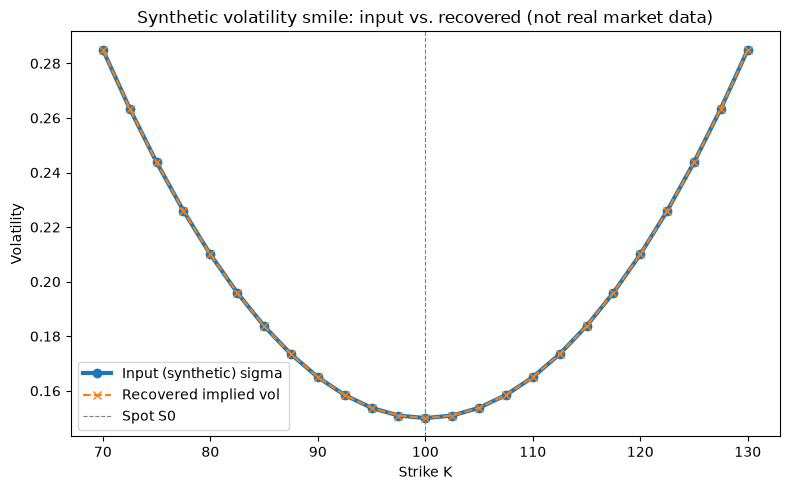

In [4]:
strikes = np.linspace(70, 130, 25)

# Purely synthetic smile shape: higher vol away from the money, minimum near K=S0.
synthetic_smile_sigma = 0.15 + 0.00015 * (strikes - S0) ** 2

synthetic_prices = [
    black_scholes_price(S0, k, T, r, sigma, option_type="call", q=q)
    for k, sigma in zip(strikes, synthetic_smile_sigma)
]
recovered_smile_sigma = [
    implied_volatility(price, S0, k, T, r, option_type="call", q=q)
    for k, price in zip(strikes, synthetic_prices)
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(strikes, synthetic_smile_sigma, "o-", label="Input (synthetic) sigma", linewidth=3)
ax.plot(strikes, recovered_smile_sigma, "x--", label="Recovered implied vol")
ax.axvline(S0, color="gray", linestyle="--", linewidth=0.8, label="Spot S0")
ax.set_xlabel("Strike K")
ax.set_ylabel("Volatility")
ax.set_title("Synthetic volatility smile: input vs. recovered (not real market data)")
ax.legend()
fig.tight_layout()
plt.show()

assert np.allclose(synthetic_smile_sigma, recovered_smile_sigma, atol=1e-6)

## 4. Impossible prices: explicit rejection

A call can never be worth more than `S*exp(-qT)` (you'd be paying more than owning the stock outright, with none of the downside protection removed). Feeding the solver a price above that bound should fail loudly, not silently return a nonsensical volatility.

In [5]:
impossible_price = S0 * 1.5  # above the S*exp(-qT) upper bound for a call

try:
    implied_volatility(impossible_price, S0, K, T, r, option_type="call", q=q)
except ValueError as exc:
    print(f"Rejected as expected: {exc}")

Rejected as expected: Price 150.0 is outside the no-arbitrage bounds (2.896925, 98.019867) for this option: no finite positive volatility can reproduce it.
